# Employee Attrition Prediction using Machine Learning

Internship Project Week 2

Task 1 – Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_score,
    recall_score,f1_score
)


In [2]:
df = pd.read_csv("F:\EmployeeAttrition_VijayKesani\WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head(10)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [6]:
attrition_rate = df['Attrition'].value_counts(normalize=True)*100
print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

In [8]:
categorical_cols = df.select_dtypes(include='object').columns

Task 2 – Data Cleaning



In [9]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [11]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [12]:
drop_cols = [
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

missing = [col for col in drop_cols if col not in df.columns]
print("Missing columns:", missing)

Missing columns: []


In [13]:
df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [14]:
df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

In [15]:
categorical_columns = df.select_dtypes(include='object').columns

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [16]:
X = df.drop('Attrition', axis=1)

y = df['Attrition']

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Task 3 – EDA

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("F:\EmployeeAttrition_VijayKesani\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df_original = df.copy()   # Keep an untouched copy

In [19]:
department_attrition = pd.crosstab(
    df_original['Department'],
    df_original['Attrition'],
    normalize='index'
) * 100

In [20]:
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

In [21]:
jobrole_attrition = pd.crosstab(
    df_original['JobRole'],
    df_original['Attrition'],
    normalize='index'
)*100

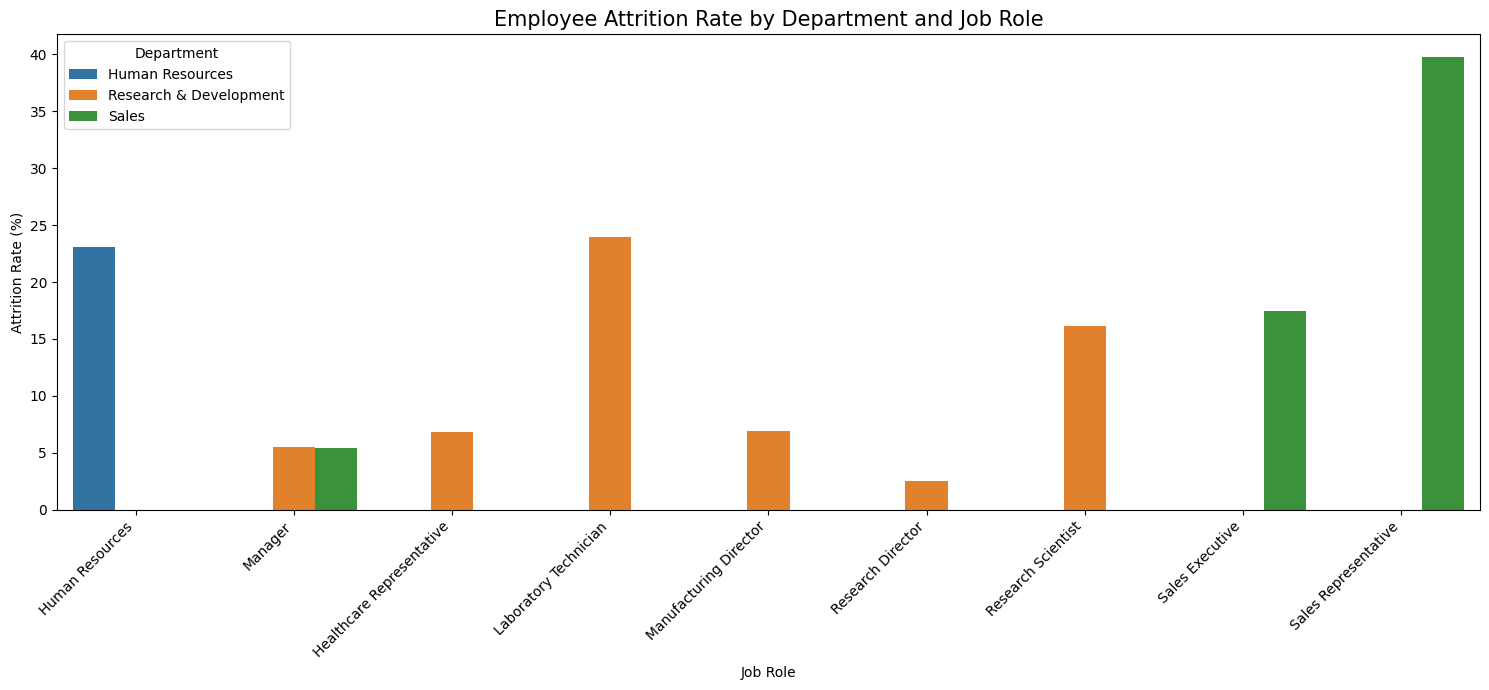

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create charts folder
os.makedirs("charts", exist_ok=True)

# Load the original dataset if df_original doesn't exist
try:
    df_original
except NameError:
    df_original = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Calculate attrition rate (%) by Department and JobRole
plot_data = (
    df_original
    .groupby(["Department", "JobRole"])["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionRate")
)

# Plot
plt.figure(figsize=(15, 7))

sns.barplot(
    data=plot_data,
    x="JobRole",
    y="AttritionRate",
    hue="Department"
)

plt.title("Employee Attrition Rate by Department and Job Role", fontsize=15)
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.legend(title="Department")
plt.tight_layout()

plt.savefig(
    "charts/attrition_department_jobrole.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

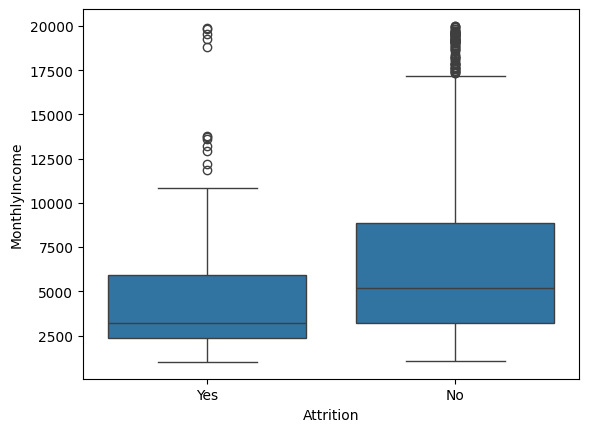

In [23]:
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

<Axes: xlabel='WorkLifeBalance', ylabel='count'>

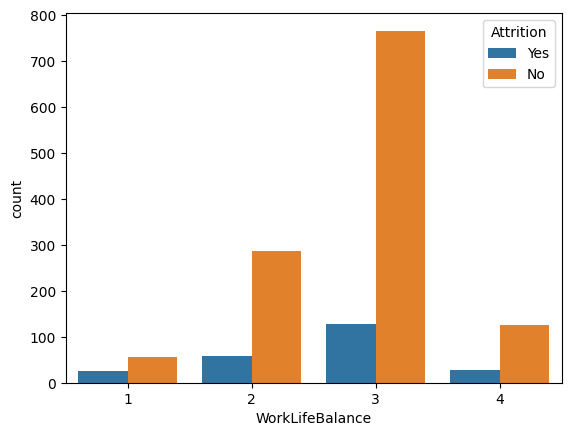

In [24]:
sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df_original
)

<Axes: xlabel='YearsAtCompany', ylabel='Count'>

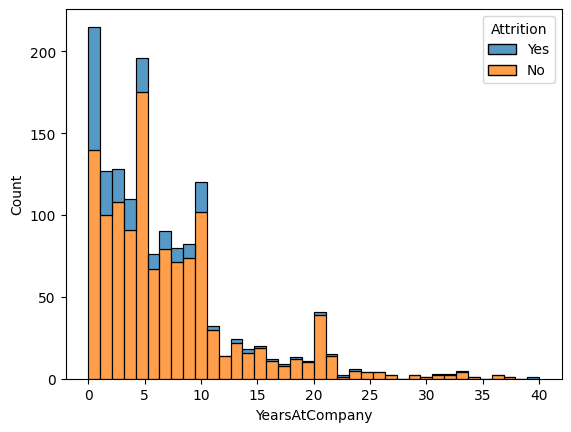

In [25]:
sns.histplot(
    data=df_original,
    x='YearsAtCompany',
    hue='Attrition',
    multiple='stack'
)

Task 4 – Model Building


In [26]:
from sklearn.model_selection import train_test_split


In [27]:
import pandas as pd
df = pd.read_csv("F:\EmployeeAttrition_VijayKesani\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df_original = df.copy()   # Keep an untouched copy

In [28]:
drop_cols = [
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

missing = [col for col in drop_cols if col not in df.columns]
print("Missing columns:", missing)

Missing columns: []


In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_original.select_dtypes(include='object').columns:
    df_original[col] = le.fit_transform(df_original[col])

In [30]:
X = df_original.drop('Attrition', axis=1)
y = df_original['Attrition']

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
lr = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [34]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

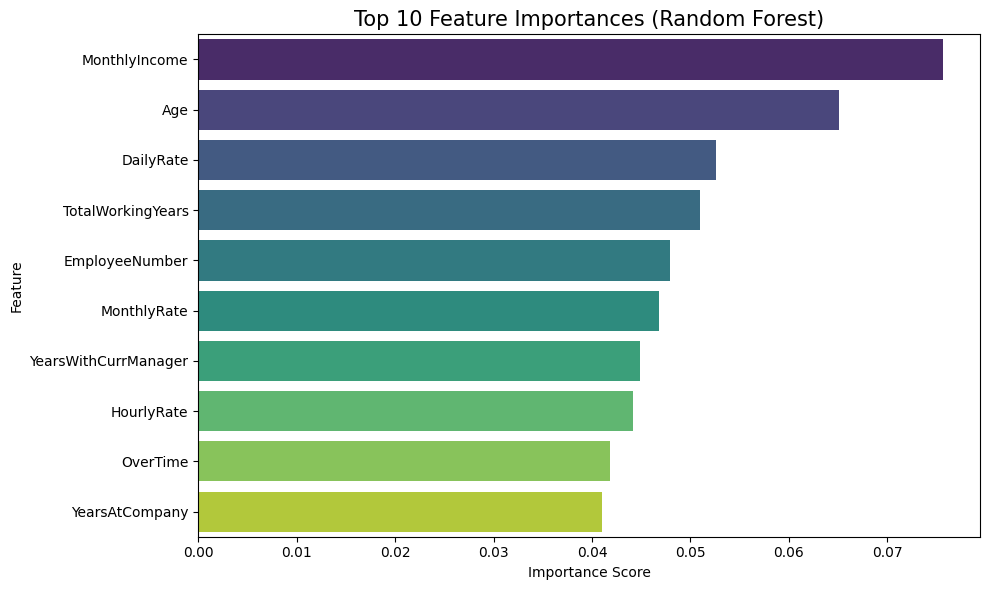

In [35]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("charts", exist_ok=True)

# Extract feature importance from Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Select Top 10 important features
top10 = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Feature Importances (Random Forest)", fontsize=15)
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

# Save chart
plt.savefig(
    "charts/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

Task 5 – Evaluation

In [37]:
def evaluate(model):

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    return [
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred),
        roc_auc_score(y_test,prob)
    ]

In [38]:
results = pd.DataFrame(
    {
        'Model':[
            'Logistic Regression',
            'Random Forest',
            'Gradient Boosting'
        ],
        'Precision':[
            evaluate(lr)[0],
            evaluate(rf)[0],
            evaluate(gb)[0]
        ],
        'Recall':[
            evaluate(lr)[1],
            evaluate(rf)[1],
            evaluate(gb)[1]
        ],
        'F1 Score':[
            evaluate(lr)[2],
            evaluate(rf)[2],
            evaluate(gb)[2]
        ],
        'ROC-AUC':[
            evaluate(lr)[3],
            evaluate(rf)[3],
            evaluate(gb)[3]
        ]
    }
)

results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.371134,0.765957,0.500000,0.802739
1,Random Forest,0.375000,0.063830,0.109091,0.760789
2,Gradient Boosting,0.562500,0.191489,0.285714,0.796365


<Axes: >

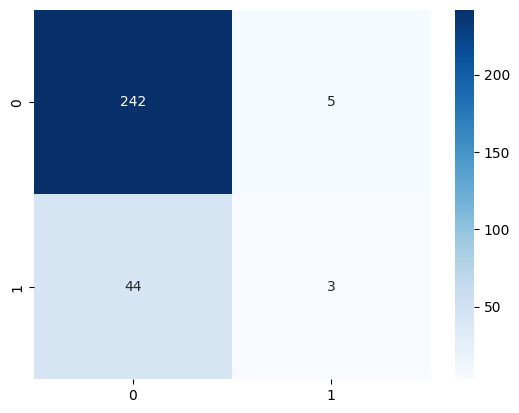

In [39]:
cm = confusion_matrix(y_test, rf.predict(X_test))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

In [40]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10)

MonthlyIncome           0.075640
Age                     0.065089
DailyRate               0.052596
TotalWorkingYears       0.050983
EmployeeNumber          0.047964
MonthlyRate             0.046852
YearsWithCurrManager    0.044929
HourlyRate              0.044173
OverTime                0.041861
YearsAtCompany          0.041042
dtype: float64

Task 6 – Charts

In [41]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
plt.savefig("charts/chart_name.png",dpi=300,bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'ROC Curve Comparison')

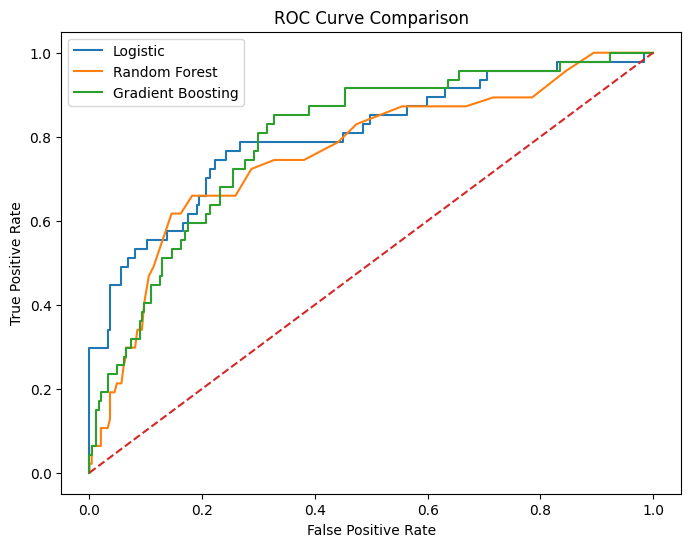

In [42]:
models = {
    'Logistic': lr,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr,tpr,_ = roc_curve(y_test,probs)
    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

Task 7 – HR Insights